In [1]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *

from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
import seaborn as sns
from scipy.stats import ttest_rel

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

palette = {'cmGC': '#c04744', 'ncmGC': "#cfb406", 'NGS': '#3171ae', 'GC': '#c04744'}


In [ ]:
data_path = '/Users/harryclark/Downloads/COHORT12/xgboost/xgboost_results.csv'
if os.path.exists(data_path):
    # save data somewhere and load it in future sessions
    data = pd.read_csv(data_path)
else:  
    path = '/Users/harryclark/Downloads/COHORT12/xgboost'
 
    data = pd.DataFrame()
    for i, file in enumerate(os.listdir(path)):
        print(f'Reading {file}, {i+1}/{len(os.listdir(path))}')
        file_path = os.path.join(path, file)
        if file.endswith('.pkl'):
            df = pd.read_pickle(file_path)
        elif file.endswith('.csv'):
            df = pd.read_csv(file_path)
        data = pd.concat([data, df], ignore_index=True)
    data.to_csv(data_path, index=False)


Reading M29_D23_C163.csv, 1/4682
Reading M21_D16_C323.csv, 2/4682
Reading M25_D25_C172.csv, 3/4682
Reading M27_D23_C291.csv, 4/4682
Reading M26_D15_C199.csv, 5/4682
Reading M21_D16_C445.csv, 6/4682
Reading M28_D23_C206.csv, 7/4682
Reading M21_D26_C101.csv, 8/4682
Reading M21_D21_C428.csv, 9/4682
Reading M21_D16_C451.csv, 10/4682
Reading M26_D18_C262.csv, 11/4682
Reading M21_D16_C337.csv, 12/4682
Reading M25_D24_C172.csv, 13/4682
Reading M21_D25_C191.csv, 14/4682
Reading M20_D23_C94.pkl, 15/4682
Reading M29_D20_C29.csv, 16/4682
Reading M25_D19_C94.csv, 17/4682
Reading M21_D21_C414.csv, 18/4682


Reading M29_D25_C476.csv, 19/4682
Reading M20_D15_C356.pkl, 20/4682
Reading M20_D25_C160.pkl, 21/4682
Reading M21_D25_C185.csv, 22/4682
Reading M26_D18_C35.csv, 23/4682
Reading M28_D19_C153.csv, 24/4682
Reading M21_D16_C486.csv, 25/4682
Reading M20_D26_C133.pkl, 26/4682
Reading M21_D16_C492.csv, 27/4682
Reading M20_D26_C127.pkl, 28/4682
Reading M29_D19_C222.csv, 29/4682
Reading M26_D15_C16.csv, 30/4682
Reading M28_D19_C147.csv, 31/4682
Reading M21_D25_C152.csv, 32/4682
Reading M29_D20_C124.csv, 33/4682
Reading M26_D15_C166.csv, 34/4682
Reading M26_D19_C289.csv, 35/4682
Reading M29_D20_C130.csv, 36/4682
Reading M26_D15_C172.csv, 37/4682
Reading M25_D25_C199.csv, 38/4682
Reading M21_D25_C146.csv, 39/4682
Reading M20_D22_C105.pkl, 40/4682
Reading M21_D26_C317.csv, 41/4682
Reading M25_D20_C193.csv, 42/4682
Reading M21_D21_C158.csv, 43/4682
Reading M29_D23_C375.csv, 44/4682
Reading M27_D26_C264.csv, 45/4682
Reading M21_D16_C135.csv, 46/4682
Reading M21_D26_C303.csv, 47/4682
Reading M20_D22_

In [ ]:
# subset dataframe to look at random order_by and session-wide pR2 
random_data = data[(data['ordering'] == 'random') &
            (data['trial_type'] == 'session') &
            (data['trial_context'] == 'session') &
            (data['trial_performance'] == 'session') &
            (data['tested_on'] != 'other')]

In [13]:
random_data

,Unnamed: 0,mouse,day,cluster_id,trained_on,tested_on,ordering,n_neurons,pR2_cv,trial_type,trial_context,trial_performance,n_filters,history_length,pR2,order_by
356,356.0,29,23,163,GC,NGS,random,0,NaN,session,session,session,5.0,1000.0,0.011373,NaN
373,373.0,29,23,163,GC,NGS,random,1,NaN,session,session,session,5.0,1000.0,0.013303,NaN
390,390.0,29,23,163,GC,NGS,random,2,NaN,session,session,session,5.0,1000.0,0.048080,NaN
407,407.0,29,23,163,GC,NGS,random,3,NaN,session,session,session,5.0,1000.0,0.064427,NaN
424,424.0,29,23,163,GC,NGS,random,4,NaN,session,session,session,5.0,1000.0,0.076175,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7598982,1257.0,27,23,288,NGS,NGS,random,20,NaN,session,session,session,5.0,1000.0,0.084235,NaN
7598999,1274.0,27,23,288,NGS,NGS,random,25,NaN,session,session,session,5.0,1000.0,0.082458,NaN
7599016,1291.0,27,23,288,NGS,NGS,random,30,NaN,session,session,session,5.0,1000.0,0.079983,NaN
7599033,1308.0,27,23,288,NGS,NGS,random,40,NaN,session,session,session,5.0,1000.0,0.087528,NaN


In [4]:
def subset_by_n_neurons(df, trained_on='GC', n_neurons=5):
    """
    Subset the dataframe to only include rows with a mouse_day_cluster_id rows which are from sessions with sufficient number of neurons.
    Args:
        df (pd.DataFrame): The input dataframe containing neuron data.
        trained_on (str): The type of neurons to filter on, e.g., 'GC' for grid cells. or 'NGS' for non-grid cells.
        n_neurons (int): The number of neurons to filter by.
    Returns:
        pd.DataFrame: A filtered dataframe
    """
    df = df[df['trained_on'] == trained_on]
    df['mouse_day_cluster_id'] = df['mouse'].astype(str) + '_' + df['day'].astype(str) + '_' + df['cluster_id'].astype(str)
    mouse_day_cluster_id_with_enough_neurons = df[df['n_neurons'] >= n_neurons]['mouse_day_cluster_id'].unique()
    df = df[df['mouse_day_cluster_id'].isin(mouse_day_cluster_id_with_enough_neurons)]
    return df[df['n_neurons'] <= n_neurons]

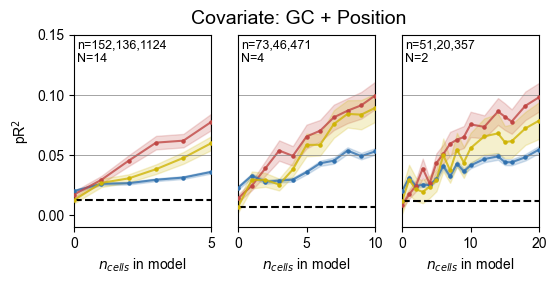

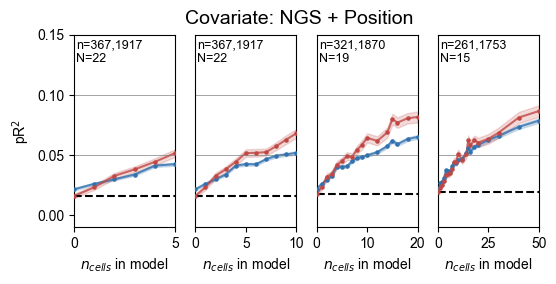

In [5]:
import matplotlib.pyplot as plt
for trained_on, bounds in zip(['GC', 'NGS'], [[[0, 5], [0, 10], [0, 20]], [[0, 5], [0, 10], [0, 20], [0, 50]]]):
    fig, axes = plt.subplots(1, len(bounds), figsize=(6, 2.5), sharey=False)
    ordered_data = random_data
    palette = {'cmGC': '#c04744', 'ncmGC': "#cfb406", 'NGS': '#3171ae', 'GC': '#c04744'}

    n_neurons_list = np.array(bounds)[:,1]
    for i, n_neurons in enumerate(n_neurons_list):
        ax = axes[i]
        valid_data = subset_by_n_neurons(ordered_data, n_neurons=n_neurons, trained_on=trained_on)
        if valid_data.empty:
            ax.axis('off')
            continue
        for tested_on in valid_data['tested_on'].unique():
            df_plot = valid_data[(valid_data['trained_on'] == trained_on) & (valid_data['tested_on'] == tested_on)]
            if df_plot.empty:
                continue
            pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
            pivot = pivot.sort_index(axis=1)
            mean = pivot.mean(axis=0)
            sem = pivot.sem(axis=0)
            count = pivot.count(axis=0)
            base_n = count.iloc[0] if len(count) > 0 else 1
            sizes = 60 * (count / base_n)
            color = palette.get(tested_on, None)
            ax.plot(mean.index, mean.values, label=f'{tested_on}', alpha=0.8, color=color)
            ax.scatter(mean.index, mean.values, s=5, color=color, zorder=3)
            ax.fill_between(mean.index, mean - sem, mean + sem, alpha=0.2, color=color)
        ax.axhline(mean.values[0], linestyle='--', color='black')
        ax.axhline(0.05, linestyle='solid', color='grey', linewidth=0.5)
        ax.axhline(0.1, linestyle='solid', color='grey', linewidth=0.5)
        ax.axhline(0.15, linestyle='solid', color='grey', linewidth=0.5)

        ax.set_xlim(bounds[i][0], bounds[i][1])
        ax.set_ylim(-0.01, 0.15)
        
        n = len(valid_data[valid_data['n_neurons'] == 1])
        
        n_cmGC = len(valid_data[(valid_data['n_neurons'] == 1) & (valid_data['tested_on'] == 'cmGC')])
        n_ncmGC = len(valid_data[(valid_data['n_neurons'] == 1) & (valid_data['tested_on'] == 'ncmGC')])
        n_GC = len(valid_data[(valid_data['n_neurons'] == 1) & (valid_data['tested_on'] == 'GC')])
        n_NGS = len(valid_data[(valid_data['n_neurons'] == 1) & (valid_data['tested_on'] == 'NGS')])
        if trained_on == 'GC':
            n_text = f'{n_cmGC},{n_ncmGC},{n_NGS}'
        elif trained_on == 'NGS':
            n_text = f'{n_GC},{n_NGS}'
        N = valid_data.groupby(['mouse', 'day']).ngroups
        ax.text(0.02, 0.98, f'n={n_text}\nN={N}', ha='left', va='top', transform=ax.transAxes, fontsize=9)
        if i == 0:
            ax.set_xticks([0,5])
        elif i == 1:
            ax.set_xticks([0,5,10])
        elif i == 2:
            ax.set_xticks([0,10,20])
        elif i == 3:
            ax.set_xticks([0,25,50])
        else:
            ax.set_xticks([])
        
        if i == 0:
            ax.set_ylabel('pR$^2$')
        else:
            ax.set_yticks([])

        ax.set_xlabel('$n_{cells}$ in model')
    fig.suptitle(f'Covariate: {trained_on} + Position', fontsize=14)
    fig.savefig(f'/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_random_ordering_trained_on_{trained_on}.pdf', bbox_inches='tight')
    plt.show()

In [ ]:
import statsmodels.formula.api as smf
for trained_on in ['GC', 'NGS']:
    trained_on_data = random_data[random_data['trained_on'] == trained_on]
    trained_on_data['mouse_day'] = trained_on_data['mouse'].astype(str) + "_" + trained_on_data['day'].astype(str)

    model = smf.mixedlm("pR2 ~ tested_on * n_neurons", trained_on_data, groups="mouse", re_formula="~1", vc_formula={"day": "0 + C(day)"})
    result = model.fit()
    print(f"Results for trained_on {trained_on}:")
    print(result.summary())

Results for trained_on GC:
                    Mixed Linear Model Regression Results
Model:                   MixedLM        Dependent Variable:        pR2       
No. Observations:        21073          Method:                    REML      
No. Groups:              7              Scale:                     0.0022    
Min. group size:         203            Log-Likelihood:            34219.1986
Max. group size:         6848           Converged:                 Yes       
Mean group size:         3010.4                                              
-----------------------------------------------------------------------------
                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------------------
Intercept                           0.027    0.008  3.553 0.000  0.012  0.042
tested_on[T.cmGC]                  -0.009    0.004 -2.451 0.014 -0.016 -0.002
tested_on[T.ncmGC]                 -0.015    0.004 -4.273

to compare pR2 across tested_on cell_types, we can cycle though the tested_on groups, making each one the reference group from which to compare the other groups against.

In [7]:
import statsmodels.formula.api as smf
import pandas as pd

data_to_use = random_data[random_data['trained_on'] == 'GC'].copy()
tested_on_groups = data_to_use['tested_on'].unique()

results = []

for ref in tested_on_groups:
    # Set reference group
    data_to_use['tested_on'] = pd.Categorical(
        data_to_use['tested_on'],
        categories=[ref] + [g for g in tested_on_groups if g != ref],
        ordered=True
    )
    model = smf.mixedlm("pR2 ~ tested_on * n_neurons", data_to_use, groups="mouse", re_formula="~1", vc_formula={"day": "0 + C(day)"})
    result = model.fit()
    # Extract coefficients, standard errors, and p-values
    params = result.params
    conf_int = result.conf_int()
    pvalues = result.pvalues
    summary_df = pd.DataFrame({
        'coef': params,
        'ci_lower': conf_int[0],
        'ci_upper': conf_int[1],
        'pval': pvalues,
        'reference': ref
    })
    results.append(summary_df.reset_index().rename(columns={'index': 'term'}))

all_results = pd.concat(results, ignore_index=True)
display(all_results)

,term,coef,ci_lower,ci_upper,pval,reference
0,Intercept,0.026788,0.012012,0.041565,0.000381,NGS
1,tested_on[T.cmGC],-0.009000,-0.016197,-0.001804,0.014238,NGS
2,tested_on[T.ncmGC],-0.015021,-0.021912,-0.008130,0.000019,NGS
3,n_neurons[T.1],0.005046,0.002066,0.008026,0.000904,NGS
4,n_neurons[T.2],0.006981,0.004001,0.009961,0.000004,NGS
...,...,...,...,...,...,...
163,tested_on[T.cmGC]:n_neurons[T.20],0.012761,-0.013358,0.038881,0.338262,ncmGC
164,tested_on[T.NGS]:n_neurons[T.25],-0.042768,-0.065067,-0.020470,0.000170,ncmGC
165,tested_on[T.cmGC]:n_neurons[T.25],0.014990,-0.011129,0.041109,0.260665,ncmGC
166,mouse Var,0.112710,-0.100508,0.325927,0.300172,ncmGC


In [8]:
# After running your model loop and creating all_results

# Filter for main effect of tested_on (at n_neurons=0) and interaction terms
main_effects = all_results[all_results['term'].str.startswith('tested_on[')]
interactions = all_results[all_results['term'].str.startswith('tested_on[') & all_results['term'].str.contains(':n_neurons')]

# Clean up term names for clarity
main_effects = main_effects.copy()
main_effects['compared_to'] = main_effects['term'].str.extract(r"tested_on\[(.+?)\]")
main_effects['effect_type'] = 'main'

interactions = interactions.copy()
interactions['compared_to'] = interactions['term'].str.extract(r"tested_on\[(.+?)\]:n_neurons")
interactions['effect_type'] = 'interaction'

# Combine and sort
summary = pd.concat([main_effects, interactions], ignore_index=True)
summary = summary[['reference', 'compared_to', 'effect_type', 'coef', 'ci_lower', 'ci_upper', 'pval']]
summary = summary.sort_values(['reference', 'effect_type', 'compared_to'])

display(summary)

,reference,compared_to,effect_type,coef,ci_lower,ci_upper,pval
108,NGS,T.cmGC,interaction,0.008020,-0.002100,0.018140,1.203664e-01
110,NGS,T.cmGC,interaction,0.022811,0.012691,0.032931,9.968038e-06
112,NGS,T.cmGC,interaction,0.033016,0.022845,0.043187,1.986010e-10
114,NGS,T.cmGC,interaction,0.030832,0.020441,0.041224,6.044357e-09
116,NGS,T.cmGC,interaction,0.041449,0.030722,0.052177,3.649048e-14
...,...,...,...,...,...,...,...
99,ncmGC,T.cmGC,main,0.014433,-0.011686,0.040552,2.787992e-01
101,ncmGC,T.cmGC,main,0.009628,-0.016491,0.035747,4.700001e-01
103,ncmGC,T.cmGC,main,0.012148,-0.013971,0.038267,3.619958e-01
105,ncmGC,T.cmGC,main,0.012761,-0.013358,0.038881,3.382624e-01


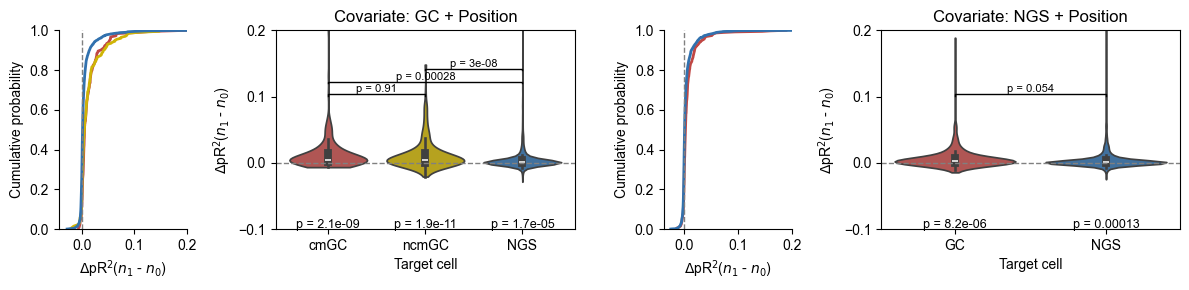

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

# --- GC analysis ---
added_pR2_gc = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'GC') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].isin([0, 1]))
    ].copy()
    df_plot['mouse_day_cluster'] = (
        df_plot['mouse'].astype(str) + '_' +
        df_plot['day'].astype(str) + '_' +
        df_plot['cluster_id'].astype(str)
    )
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    temp_df = pd.DataFrame({
        'added_pR2': pivot[1] - pivot[0],
        'tested_on': tested_on,
        'mouse': [idx[0] for idx in pivot.index],
        'day': [idx[1] for idx in pivot.index],
        'cluster_id': [idx[2] for idx in pivot.index]
    })
    added_pR2_gc.append(temp_df)
added_pR2_gc = pd.concat(added_pR2_gc, ignore_index=True)

# Pairwise LMM p-values for GC (refit for each comparison)
gc_groups = ['cmGC', 'ncmGC', 'NGS']
vc_gc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_gc = {}
for g1, g2 in [('cmGC', 'ncmGC'), ('cmGC', 'NGS'), ('ncmGC', 'NGS')]:
    temp = added_pR2_gc.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_gc[(g1, g2)] = result.pvalues.get(term, np.nan)

# Refit LMM for GC with each group as reference to get test against zero for each group
gc_zero_pvals = {}
for ref in gc_groups:
    temp = added_pR2_gc.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in gc_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    gc_zero_pvals[ref] = result.pvalues['Intercept']

# --- NGS analysis ---
added_pR2_ngs = []
for tested_on in ['GC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'NGS') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].isin([0, 1]))
    ].copy()
    df_plot['mouse_day_cluster'] = (
        df_plot['mouse'].astype(str) + '_' +
        df_plot['day'].astype(str) + '_' +
        df_plot['cluster_id'].astype(str)
    )
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    temp_df = pd.DataFrame({
        'added_pR2': pivot[1] - pivot[0],
        'tested_on': tested_on,
        'mouse': [idx[0] for idx in pivot.index],
        'day': [idx[1] for idx in pivot.index],
        'cluster_id': [idx[2] for idx in pivot.index]
    })
    added_pR2_ngs.append(temp_df)
added_pR2_ngs = pd.concat(added_pR2_ngs, ignore_index=True)

# Pairwise LMM p-values for NGS (refit for each comparison)
ngs_groups = ['GC', 'NGS']
vc_ngs = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_ngs = {}
for g1, g2 in [('GC', 'NGS')]:
    temp = added_pR2_ngs.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_ngs[(g1, g2)] = result.pvalues.get(term, np.nan)

# Refit LMM for NGS with each group as reference to get test against zero for each group
ngs_zero_pvals = {}
for ref in ngs_groups:
    temp = added_pR2_ngs.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in ngs_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    ngs_zero_pvals[ref] = result.pvalues['Intercept']

# --- Combined Figure ---
fig, axes = plt.subplots(1, 4, figsize=(12, 3), width_ratios=[0.3, 0.7, 0.3, 0.7])

# GC CDF
groups_gc = ['cmGC', 'ncmGC', 'NGS']
ax_gc_cdf = axes[0]
for group in groups_gc:
    vals = added_pR2_gc[added_pR2_gc['tested_on'] == group]['added_pR2'].dropna()
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax_gc_cdf.plot(sorted_vals, cdf, label=group, color=palette[group], lw=2)
ax_gc_cdf.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_cdf.set_xlabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_gc_cdf.set_ylabel('Cumulative probability')
ax_gc_cdf.set_xlim(None, 0.2)
ax_gc_cdf.set_ylim(0, 1)
ax_gc_cdf.spines['top'].set_visible(False)
ax_gc_cdf.spines['right'].set_visible(False)

# GC Violin
ax_gc_violin = axes[1]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_violin
)
ax_gc_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_violin.set_ylabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_gc_violin.set_xlabel('Target cell')
ax_gc_violin.set_title('Covariate: GC + Position')
ax_gc_violin.set_ylim(-0.075, 0.2)
y_max = 0.1
y_min = added_pR2_gc['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * y_range
for idx, ((g1, g2), pval) in enumerate(pvals_gc.items()):
    x1, x2 = groups_gc.index(g1), groups_gc.index(g2)
    y = y_start + idx * step
    ax_gc_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_gc_violin.set_yticks([-0.1, 0, 0.1, 0.2])
y_bottom = ax_gc_violin.get_ylim()[0] + 0.015
for i, group in enumerate(groups_gc):
    ax_gc_violin.text(i, y_bottom, f"p = {gc_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# NGS CDF
groups_ngs = ['GC', 'NGS']
ax_ngs_cdf = axes[2]
for group in groups_ngs:
    vals = added_pR2_ngs[added_pR2_ngs['tested_on'] == group]['added_pR2'].dropna()
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax_ngs_cdf.plot(sorted_vals, cdf, color=palette[group], lw=2)
ax_ngs_cdf.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_cdf.set_xlabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_ngs_cdf.set_ylabel('Cumulative probability')
ax_ngs_cdf.set_xlim(None, 0.2)
ax_ngs_cdf.set_ylim(0, 1)
ax_ngs_cdf.spines['top'].set_visible(False)
ax_ngs_cdf.spines['right'].set_visible(False)

# NGS Violin
ax_ngs_violin = axes[3]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_violin
)
ax_ngs_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_violin.set_ylabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_ngs_violin.set_xlabel('Target cell')
ax_ngs_violin.set_title('Covariate: NGS + Position')
ax_ngs_violin.set_ylim(-0.075, 0.2)
y_max = 0.1
y_min = added_pR2_ngs['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * step
for idx, ((g1, g2), pval) in enumerate(pvals_ngs.items()):
    x1, x2 = groups_ngs.index(g1), groups_ngs.index(g2)
    y = y_start + idx * step
    ax_ngs_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_ngs_violin.set_yticks([-0.1, 0, 0.1, 0.2])
y_bottom = ax_ngs_violin.get_ylim()[0] + 0.015
for i, group in enumerate(groups_ngs):
    ax_ngs_violin.text(i, y_bottom, f"p = {ngs_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')
plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_gc_ngs_combined_4col.pdf', bbox_inches='tight')
plt.show()

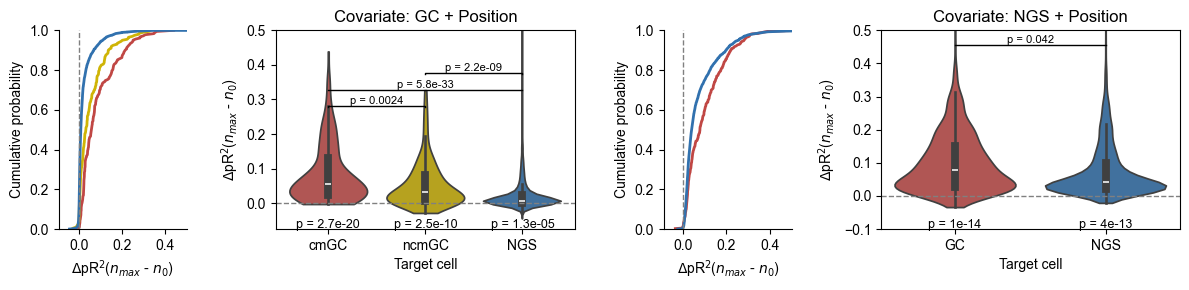

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

# --- GC analysis (max n_neurons) ---
added_pR2_gc_max = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'GC') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_gc_max.append(temp_df)
added_pR2_gc_max = pd.concat(added_pR2_gc_max, ignore_index=True)

# Pairwise LMM p-values for GC (max n_neurons, refit for each comparison)
gc_groups = ['cmGC', 'ncmGC', 'NGS']
vc_gc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_gc = {}
for g1, g2 in [('cmGC', 'ncmGC'), ('cmGC', 'NGS'), ('ncmGC', 'NGS')]:
    temp = added_pR2_gc_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_gc[(g1, g2)] = result.pvalues.get(term, np.nan)

# Refit LMM for GC with each group as reference to get test against zero for each group
gc_zero_pvals = {}
for ref in gc_groups:
    temp = added_pR2_gc_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in gc_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    gc_zero_pvals[ref] = result.pvalues['Intercept']

# --- NGS analysis (max n_neurons) ---
added_pR2_ngs_max = []
for tested_on in ['GC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'NGS') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_ngs_max.append(temp_df)
added_pR2_ngs_max = pd.concat(added_pR2_ngs_max, ignore_index=True)

# Pairwise LMM p-values for NGS (max n_neurons, refit for each comparison)
ngs_groups = ['GC', 'NGS']
vc_ngs = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_ngs = {}
for g1, g2 in [('GC', 'NGS')]:
    temp = added_pR2_ngs_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_ngs[(g1, g2)] = result.pvalues.get(term, np.nan)

# Refit LMM for NGS with each group as reference to get test against zero for each group
ngs_zero_pvals = {}
for ref in ngs_groups:
    temp = added_pR2_ngs_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in ngs_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    ngs_zero_pvals[ref] = result.pvalues['Intercept']

# --- Combined Figure ---
fig, axes = plt.subplots(1, 4, figsize=(12, 3), width_ratios=[0.3, 0.7, 0.3, 0.7])

# GC max CDF
ax_gc_cdf = axes[0]
for group in gc_groups:
    vals = added_pR2_gc_max[added_pR2_gc_max['tested_on'] == group]['added_pR2'].dropna()
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax_gc_cdf.plot(sorted_vals, cdf, label=group, color=palette[group], lw=2)
ax_gc_cdf.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_cdf.set_xlabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_gc_cdf.set_ylabel('Cumulative probability')
ax_gc_cdf.set_xlim(None, 0.5)
ax_gc_cdf.set_ylim(0, 1)
ax_gc_cdf.spines['top'].set_visible(False)
ax_gc_cdf.spines['right'].set_visible(False)

# GC max Violin
ax_gc_violin = axes[1]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_violin
)
ax_gc_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_gc_violin.set_xlabel('Target cell')
ax_gc_violin.set_title('Covariate: GC + Position')
ax_gc_violin.set_ylim(-0.075, 0.5)
y_max = 0.275
y_min = added_pR2_gc_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * y_range
for idx, ((g1, g2), pval) in enumerate(pvals_gc.items()):
    x1, x2 = gc_groups.index(g1), gc_groups.index(g2)
    y = y_start + idx * step
    ax_gc_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
y_bottom = ax_gc_violin.get_ylim()[0] + 0.03
for i, group in enumerate(gc_groups):
    ax_gc_violin.text(i, y_bottom, f"p = {gc_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# NGS max CDF
ax_ngs_cdf = axes[2]
for group in ngs_groups:
    vals = added_pR2_ngs_max[added_pR2_ngs_max['tested_on'] == group]['added_pR2'].dropna()
    sorted_vals = np.sort(vals)
    cdf = np.arange(1, len(sorted_vals)+1) / len(sorted_vals)
    ax_ngs_cdf.plot(sorted_vals, cdf, color=palette[group], lw=2)
ax_ngs_cdf.axvline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_cdf.set_xlabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_ngs_cdf.set_ylabel('Cumulative probability')
ax_ngs_cdf.set_xlim(None, 0.5)
ax_ngs_cdf.set_ylim(0, 1)
ax_ngs_cdf.spines['top'].set_visible(False)
ax_ngs_cdf.spines['right'].set_visible(False)

# NGS max Violin
ax_ngs_violin = axes[3]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_violin
)
ax_ngs_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_ngs_violin.set_xlabel('Target cell')
ax_ngs_violin.set_title('Covariate: NGS + Position')
ax_ngs_violin.set_ylim(-0.1, 0.5)
y_max = 0.45
y_min = added_pR2_ngs_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * y_range
for idx, ((g1, g2), pval) in enumerate(pvals_ngs.items()):
    x1, x2 = ngs_groups.index(g1), ngs_groups.index(g2)
    y = y_start + idx * step
    ax_ngs_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
y_bottom = ax_ngs_violin.get_ylim()[0] + 0.03
for i, group in enumerate(ngs_groups):
    ax_ngs_violin.text(i, y_bottom, f"p = {ngs_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

plt.tight_layout()
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_max_gc_ngs_combined_4col_lmm.pdf', bbox_inches='tight')
plt.show()

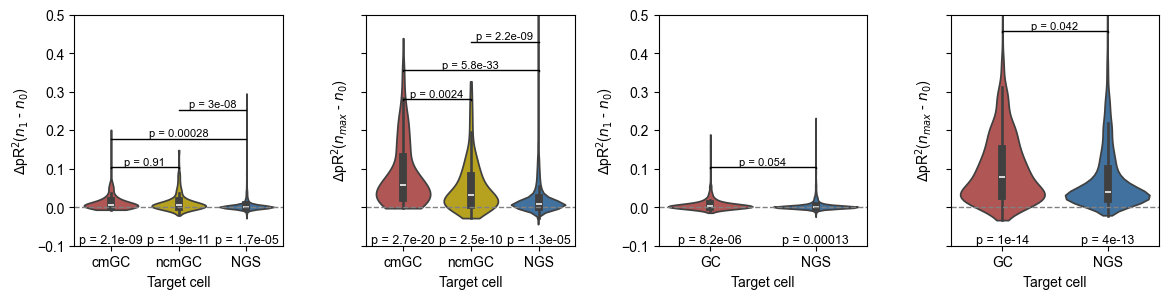

: 

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import statsmodels.formula.api as smf
import pandas as pd

# --- GC analysis ---
added_pR2_gc = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'GC') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].isin([0, 1]))
    ].copy()
    df_plot['mouse_day_cluster'] = (
        df_plot['mouse'].astype(str) + '_' +
        df_plot['day'].astype(str) + '_' +
        df_plot['cluster_id'].astype(str)
    )
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    temp_df = pd.DataFrame({
        'added_pR2': pivot[1] - pivot[0],
        'tested_on': tested_on,
        'mouse': [idx[0] for idx in pivot.index],
        'day': [idx[1] for idx in pivot.index],
        'cluster_id': [idx[2] for idx in pivot.index]
    })
    added_pR2_gc.append(temp_df)
added_pR2_gc = pd.concat(added_pR2_gc, ignore_index=True)

gc_groups = ['cmGC', 'ncmGC', 'NGS']
vc_gc = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_gc = {}
for g1, g2 in [('cmGC', 'ncmGC'), ('cmGC', 'NGS'), ('ncmGC', 'NGS')]:
    temp = added_pR2_gc.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_gc[(g1, g2)] = result.pvalues.get(term, np.nan)

gc_zero_pvals = {}
for ref in gc_groups:
    temp = added_pR2_gc.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in gc_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    gc_zero_pvals[ref] = result.pvalues['Intercept']

# --- NGS analysis ---
added_pR2_ngs = []
for tested_on in ['GC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'NGS') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].isin([0, 1]))
    ].copy()
    df_plot['mouse_day_cluster'] = (
        df_plot['mouse'].astype(str) + '_' +
        df_plot['day'].astype(str) + '_' +
        df_plot['cluster_id'].astype(str)
    )
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    pivot = pivot.dropna(subset=[0, 1])
    temp_df = pd.DataFrame({
        'added_pR2': pivot[1] - pivot[0],
        'tested_on': tested_on,
        'mouse': [idx[0] for idx in pivot.index],
        'day': [idx[1] for idx in pivot.index],
        'cluster_id': [idx[2] for idx in pivot.index]
    })
    added_pR2_ngs.append(temp_df)
added_pR2_ngs = pd.concat(added_pR2_ngs, ignore_index=True)

ngs_groups = ['GC', 'NGS']
vc_ngs = {
    "day": "0 + C(day)",
    "cluster": "0 + C(cluster_id)"
}
pvals_ngs = {}
for g1, g2 in [('GC', 'NGS')]:
    temp = added_pR2_ngs.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_ngs[(g1, g2)] = result.pvalues.get(term, np.nan)

ngs_zero_pvals = {}
for ref in ngs_groups:
    temp = added_pR2_ngs.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in ngs_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    ngs_zero_pvals[ref] = result.pvalues['Intercept']

# --- GC analysis (max n_neurons) ---
added_pR2_gc_max = []
for tested_on in ['cmGC', 'ncmGC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'GC') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_gc_max.append(temp_df)
added_pR2_gc_max = pd.concat(added_pR2_gc_max, ignore_index=True)

pvals_gc_max = {}
for g1, g2 in [('cmGC', 'ncmGC'), ('cmGC', 'NGS'), ('ncmGC', 'NGS')]:
    temp = added_pR2_gc_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_gc_max[(g1, g2)] = result.pvalues.get(term, np.nan)

gc_zero_pvals_max = {}
for ref in gc_groups:
    temp = added_pR2_gc_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in gc_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_gc)
    result = model.fit()
    gc_zero_pvals_max[ref] = result.pvalues['Intercept']

# --- NGS analysis (max n_neurons) ---
added_pR2_ngs_max = []
for tested_on in ['GC', 'NGS']:
    df_plot = random_data[
        (random_data['trained_on'] == 'NGS') &
        (random_data['tested_on'] == tested_on) &
        (random_data['n_neurons'].notna())
    ].copy()
    pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
    valid_rows = pivot.dropna(subset=[0])
    diffs = []
    for idx, row in valid_rows.iterrows():
        nonzero_cols = [col for col in row.index if col != 0 and not pd.isna(row[col])]
        if len(nonzero_cols) == 0:
            continue
        max_n = max(nonzero_cols)
        diff = row[max_n] - row[0]
        diffs.append({'added_pR2': diff, 'tested_on': tested_on, 'mouse': idx[0], 'day': idx[1], 'cluster_id': idx[2], 'max_n_neurons': max_n})
    temp_df = pd.DataFrame(diffs)
    added_pR2_ngs_max.append(temp_df)
added_pR2_ngs_max = pd.concat(added_pR2_ngs_max, ignore_index=True)

pvals_ngs_max = {}
for g1, g2 in [('GC', 'NGS')]:
    temp = added_pR2_ngs_max.copy()
    temp = temp[temp['tested_on'].isin([g1, g2])]
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[g1, g2], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    term = f'tested_on[T.{g2}]'
    pvals_ngs_max[(g1, g2)] = result.pvalues.get(term, np.nan)

ngs_zero_pvals_max = {}
for ref in ngs_groups:
    temp = added_pR2_ngs_max.copy()
    temp['tested_on'] = pd.Categorical(temp['tested_on'], categories=[ref] + [g for g in ngs_groups if g != ref], ordered=True)
    model = smf.mixedlm("added_pR2 ~ tested_on", temp, groups=temp["mouse"], vc_formula=vc_ngs)
    result = model.fit()
    ngs_zero_pvals_max[ref] = result.pvalues['Intercept']

# --- Combined Figure (Violin only, 4 columns) ---
fig, axes = plt.subplots(1, 4, figsize=(14, 3), width_ratios=[0.7, 0.7, 0.7, 0.7])

# GC covariate violin (n=1)
ax_gc_violin = axes[0]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_violin
)
ax_gc_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_violin.set_ylabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_gc_violin.set_xlabel('Target cell')
ax_gc_violin.set_ylim(-0.075, 0.2)
y_max = 0.1
y_min = added_pR2_gc['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_gc.items()):
    x1, x2 = gc_groups.index(g1), gc_groups.index(g2)
    y = y_start + idx * step
    ax_gc_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_gc_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
y_bottom = -0.07
for i, group in enumerate(gc_groups):
    ax_gc_violin.text(i, y_bottom, f"p = {gc_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# GC covariate violin (max n)
ax_gc_max_violin = axes[1]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_gc_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_gc_max_violin
)
ax_gc_max_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_gc_max_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_gc_max_violin.set_xlabel('Target cell')
ax_gc_max_violin.set_ylim(-0.075, 0.5)
y_max = 0.275
y_min = added_pR2_gc_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_gc_max.items()):
    x1, x2 = gc_groups.index(g1), gc_groups.index(g2)
    y = y_start + idx * step
    ax_gc_max_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_gc_max_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_gc_max_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax_gc_max_violin.set_yticklabels(['', '', '', '', '', '', ''])
y_bottom = -0.07
for i, group in enumerate(gc_groups):
    ax_gc_max_violin.text(i, y_bottom, f"p = {gc_zero_pvals_max[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# NGS covariate violin (n=1)
ax_ngs_violin = axes[2]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_violin
)
ax_ngs_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_violin.set_ylabel('$\\Delta$pR$^2$($n_{1}$ - $n_{0}$)')
ax_ngs_violin.set_xlabel('Target cell')
ax_ngs_violin.set_ylim(-0.075, 0.2)
y_max = 0.1
y_min = added_pR2_ngs['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_ngs.items()):
    x1, x2 = ngs_groups.index(g1), ngs_groups.index(g2)
    y = y_start + idx * step
    ax_ngs_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_ngs_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
y_bottom = -0.07
for i, group in enumerate(ngs_groups):
    ax_ngs_violin.text(i, y_bottom, f"p = {ngs_zero_pvals[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

# NGS covariate violin (max n)
ax_ngs_max_violin = axes[3]
sns.violinplot(
    x='tested_on',
    y='added_pR2',
    data=added_pR2_ngs_max,
    inner='box',
    cut=0,
    palette=palette,
    ax=ax_ngs_max_violin
)
ax_ngs_max_violin.axhline(0, color='gray', linestyle='--', linewidth=1)
ax_ngs_max_violin.set_ylabel('$\\Delta$pR$^2$($n_{max}$ - $n_{0}$)')
ax_ngs_max_violin.set_xlabel('Target cell')
ax_ngs_max_violin.set_ylim(-0.1, 0.5)
y_max = 0.45
y_min = added_pR2_ngs_max['added_pR2'].min()
y_range = y_max - y_min
y_start = y_max + 0.01 * y_range
step = 0.15 * 0.5
for idx, ((g1, g2), pval) in enumerate(pvals_ngs_max.items()):
    x1, x2 = ngs_groups.index(g1), ngs_groups.index(g2)
    y = y_start + idx * step
    ax_ngs_max_violin.plot([x1, x1, x2, x2], [y, y+0.002, y+0.002, y], lw=1, c='k')
    ax_ngs_max_violin.text((x1 + x2) / 2, y + 0.002, f"p = {pval:.2g}", ha='center', va='bottom', fontsize=8)
ax_ngs_max_violin.set_yticks([-0.1, 0, 0.1, 0.2, 0.3, 0.4, 0.5])
ax_ngs_max_violin.set_yticklabels(['', '', '', '', '', '', ''])
y_bottom = -0.07
for i, group in enumerate(ngs_groups):
    ax_ngs_max_violin.text(i, y_bottom, f"p = {ngs_zero_pvals_max[group]:.2g}", ha='center', va='top', fontsize=9, color='black')

plt.subplots_adjust(wspace=0.4)  # Custom spacing between subplots
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_gc_ngs_violin_only_4col.pdf', bbox_inches='tight')
plt.show()

now we want to split up the data into two different recording set ups, the recordings were either run across whole shanks or horizontal sections across multiple shanks. We can use this division to look at whether the nearest versus farther differences are only as a result of one of the recording types. For example, if there is only a clear difference in the 'v' or 'vertical' condition, then this implies that dorso ventral connects are more informative than medial-lateral connections

In [ ]:

mouse_day_config = {
    20: [(14,'h'), (15,'h'), (16,'h'), (17,'h'), (18,'h'), (19,'h'), (20,'v'), (21,'v'), (22,'v'), (23,'v'), (24,'v'), (25,'v'), (26,'v')],
    21: [(15,'h'), (16,'h'), (17,'h'), (18,'h'), (19,'v'), (20,'v'), (21,'v'), (22,'h'), (23,'v'), (24,'v'), (25,'v'), (26,'v')],
    25: [(16,'h'), (17,'h'), (18,'h'), (19,'v'), (20,'v'), (21,'v'), (22,'v'), (23,'v'), (24,'v'), (25,'h')],
    26: [(11,'v'), (12,'v'), (13,'h'), (14,'v'), (15,'h'), (16,'h'), (17,'v'), (18,'v'), (19,'h')],
    27: [(16,'h'), (17,'h'), (18,'h'), (19,'h'), (20,'v'), (21,'v'), (22,'v'), (23,'v'), (24,'v'), (26,'v')],
    28: [(16,'h'), (17,'h'), (18,'h'), (19,'v'), (20,'v'), (21,'v'), (22,'v'), (23,'h'), (25,'h')],
    29: [(16,'h'), (17,'h'), (18,'h'), (19,'v'), (20,'v'), (21,'v'), (22,'v'), (23,'h'), (25,'h')],
}

In [ ]:
# Add a 'recording_config' column to your dataframe using mouse_day_config

def get_recording_config(row):
    mouse = row['mouse']
    day = row['day']
    configs = mouse_day_config.get(mouse, [])
    for d, config in configs:
        if d == day:
            return config
    return None

nearest_data['recording_config'] = nearest_data.apply(get_recording_config, axis=1)
farthest_data['recording_config'] = farthest_data.apply(get_recording_config, axis=1)
random_data['recording_config'] = random_data.apply(get_recording_config, axis=1)

In [ ]:
from scipy.stats import ttest_ind, ttest_1samp
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare split data for each tested_on group for trained_on='GC'
added_pR2 = []
for source, source_data in zip(['nearest', 'farthest'], [nearest_data, farthest_data]):
    for tested_on in ['cmGC', 'ncmGC', 'NGS']:
        df_plot = source_data[(source_data['recording_config'] == 'v') &
                              (source_data['trained_on'] == 'GC') & 
                              (source_data['tested_on'] == tested_on) & 
                              (source_data['n_neurons'].isin([0, 1]))]
        pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
        pivot = pivot.dropna(subset=[0, 1])
        diff = pivot[1] - pivot[0]
        temp_df = pd.DataFrame({
            'added_pR2': diff,
            'tested_on': tested_on,
            'source': source
        })
        added_pR2.append(temp_df)

added_pR2 = pd.concat(added_pR2, ignore_index=True)


plt.figure(figsize=(4, 3))
ax = sns.violinplot(
    x='tested_on',
    y='added_pR2',
    hue='source',
    data=added_pR2,
    split=True,
    inner='box',
    cut=0,
    palette=source_palette
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Added pR$^2$\n($n_{cells}=1$ - $n_{cells}=0$)')
plt.xlabel('Tested on')
plt.title('Trained on GC (single shank)\nNearest vs Farthest')
plt.tight_layout()
plt.ylim(-0.075, 0.2)
plt.legend(title='Source', loc='upper right', frameon=False)

# Annotate p-values comparing nearest vs farthest for each group
groups = ['cmGC', 'ncmGC', 'NGS']
y_max = 0.15
for i, group in enumerate(groups):
    nearest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'nearest')]['added_pR2']
    farthest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'farthest')]['added_pR2']
    tstat, pval = ttest_ind(nearest_vals, farthest_vals, nan_policy='omit')
    ax.text(i, y_max, f"p={pval:.2g}", ha='center', va='bottom', fontsize=9, color='black')
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_trained_on_gc_nearest_vs_farthest_recording_config_v.pdf', bbox_inches='tight')
plt.show()

In [ ]:
from scipy.stats import ttest_ind, ttest_1samp
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare split data for each tested_on group for trained_on='GC'
added_pR2 = []
for source, source_data in zip(['nearest', 'farthest'], [nearest_data, farthest_data]):
    for tested_on in ['cmGC', 'ncmGC', 'NGS']:
        df_plot = source_data[(source_data['recording_config'] == 'h') &
                              (source_data['trained_on'] == 'GC') & 
                              (source_data['tested_on'] == tested_on) & 
                              (source_data['n_neurons'].isin([0, 1]))]
        pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
        pivot = pivot.dropna(subset=[0, 1])
        diff = pivot[1] - pivot[0]
        temp_df = pd.DataFrame({
            'added_pR2': diff,
            'tested_on': tested_on,
            'source': source
        })
        added_pR2.append(temp_df)

added_pR2 = pd.concat(added_pR2, ignore_index=True)


plt.figure(figsize=(4, 3))
ax = sns.violinplot(
    x='tested_on',
    y='added_pR2',
    hue='source',
    data=added_pR2,
    split=True,
    inner='box',
    cut=0,
    palette=source_palette
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Added pR$^2$\n($n_{cells}=1$ - $n_{cells}=0$)')
plt.xlabel('Tested on')
plt.title('Trained on GC (multi-shank)\nNearest vs Farthest')
plt.tight_layout()
plt.ylim(-0.075, 0.1)
plt.legend(title='Source', loc='upper right', frameon=False)

# Annotate p-values comparing nearest vs farthest for each group
groups = ['cmGC', 'ncmGC', 'NGS']
y_max = 0.15
for i, group in enumerate(groups):
    nearest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'nearest')]['added_pR2']
    farthest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'farthest')]['added_pR2']
    tstat, pval = ttest_ind(nearest_vals, farthest_vals, nan_policy='omit')
    ax.text(i, y_max, f"p={pval:.2g}", ha='center', va='bottom', fontsize=9, color='black')
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_trained_on_gc_nearest_vs_farthest_recording_config_h.pdf', bbox_inches='tight')
plt.show()

In [ ]:
from scipy.stats import ttest_ind, ttest_1samp
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare split data for each tested_on group
added_pR2 = []
for source, source_data in zip(['nearest', 'farthest'], [nearest_data, farthest_data]):
    for tested_on in ['GC', 'NGS']:
        df_plot = source_data[(source_data['recording_config'] == 'v') &
                              (source_data['trained_on'] == 'NGS') & 
                              (source_data['tested_on'] == tested_on) & 
                              (source_data['n_neurons'].isin([0, 1]))]
        pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
        pivot = pivot.dropna(subset=[0, 1])
        diff = pivot[1] - pivot[0]
        temp_df = pd.DataFrame({
            'added_pR2': diff,
            'tested_on': tested_on,
            'source': source
        })
        added_pR2.append(temp_df)

added_pR2 = pd.concat(added_pR2, ignore_index=True)


plt.figure(figsize=(4, 3))
ax = sns.violinplot(
    x='tested_on',
    y='added_pR2',
    hue='source',
    data=added_pR2,
    split=True,
    inner='box',
    cut=0,
    palette=source_palette
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Added pR$^2$\n($N_{cells}=1$ - $N_{cells}=0$)')
plt.xlabel('Tested on')
plt.title('Trained on NGS (single shank)\nNearest vs Farthest')
plt.tight_layout()
plt.ylim(-0.075, 0.2)
plt.legend(title='Source', loc='upper right', frameon=False)

# Annotate p-values comparing nearest vs farthest for each group
groups = ['GC', 'NGS']
y_max = 0.15
for i, group in enumerate(groups):
    nearest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'nearest')]['added_pR2']
    farthest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'farthest')]['added_pR2']
    tstat, pval = ttest_ind(nearest_vals, farthest_vals, nan_policy='omit')
    ax.text(i, y_max, f"p={pval:.2g}", ha='center', va='bottom', fontsize=9, color='black')
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_trained_on_ngs_nearest_vs_farthest_recording_config_v.pdf', bbox_inches='tight')
plt.show()

In [ ]:
from scipy.stats import ttest_ind, ttest_1samp
import seaborn as sns
import matplotlib.pyplot as plt

# Prepare split data for each tested_on group
added_pR2 = []
for source, source_data in zip(['nearest', 'farthest'], [nearest_data, farthest_data]):
    for tested_on in ['GC', 'NGS']:
        df_plot = source_data[(source_data['recording_config'] == 'h') &
                              (source_data['trained_on'] == 'NGS') & 
                              (source_data['tested_on'] == tested_on) & 
                              (source_data['n_neurons'].isin([0, 1]))]
        pivot = df_plot.pivot_table(index=['mouse', 'day', 'cluster_id'], columns='n_neurons', values='pR2')
        pivot = pivot.dropna(subset=[0, 1])
        diff = pivot[1] - pivot[0]
        temp_df = pd.DataFrame({
            'added_pR2': diff,
            'tested_on': tested_on,
            'source': source
        })
        added_pR2.append(temp_df)

added_pR2 = pd.concat(added_pR2, ignore_index=True)

plt.figure(figsize=(4, 3))
ax = sns.violinplot(
    x='tested_on',
    y='added_pR2',
    hue='source',
    data=added_pR2,
    split=True,
    inner='box',
    cut=0,
    palette=source_palette
)
plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.ylabel('Added pR$^2$\n($N_{cells}=1$ - $N_{cells}=0$)')
plt.xlabel('Tested on')
plt.title('Trained on NGS (multi-shank)\nNearest vs Farthest')
plt.tight_layout()
plt.ylim(-0.075, 0.1)
plt.legend(title='Source', loc='upper right', frameon=False)

# Annotate p-values comparing nearest vs farthest for each group
groups = ['GC', 'NGS']
y_max = 0.15
for i, group in enumerate(groups):
    nearest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'nearest')]['added_pR2']
    farthest_vals = added_pR2[(added_pR2['tested_on'] == group) & (added_pR2['source'] == 'farthest')]['added_pR2']
    tstat, pval = ttest_ind(nearest_vals, farthest_vals, nan_policy='omit')
    ax.text(i, y_max, f"p={pval:.2g}", ha='center', va='bottom', fontsize=9, color='black')
plt.savefig('/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_3_xgboost/xgboost_added_pR2_trained_on_ngs_nearest_vs_farthest_recording_config_h.pdf', bbox_inches='tight')
plt.show()